In [1]:
# Импорт библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [21]:
# работа будет проводиться в Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Подготовка и загрузка данных

In [3]:
!unzip /content/drive/MyDrive/CV_project1_data.zip -d /content/CV_project1_data

Archive:  /content/drive/MyDrive/CV_project1_data.zip
  inflating: /content/CV_project1_data/data/train/bill_gates/006f6dcf-315f-4291-80d2-b61054210273.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/00715f3e-b281-4199-91c7-7da7a8475d7b.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/00a6f308-78d3-4ebc-b441-23aebc81ddff.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/00b4268f-0870-486c-98b0-9d13e6834525.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/011e2141-db98-43a5-ba17-2dbe3a7604c0.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/0121cf2a-33d3-425b-aca7-6a03de5cbd1e.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/01292fb3-5ed1-4f1b-8f3e-cbab05095b60.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/01333537-d705-4507-ba7f-04b6ba863850.jpg  
  inflating: /content/CV_project1_data/data/train/bill_gates/016517ba-0d8d-46b3-8b34-0226b2ed4d6d.jpg  
  inflatin

In [4]:
data_dir = '/content/CV_project1_data/data/'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'valid')

In [5]:
# Задаем размер батча
batch_size = 32

In [6]:
# Трансформации данных. Для тренировочного набора добавим аугментацию!
# Аугментация помогает бороться с переобучением, искусственно расширяя датасет.
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # Случайная обрезка и ресайз под стандарт ImageNet
        transforms.RandomHorizontalFlip(), # Случайное отзеркаливание
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # Изменение цвета
        transforms.ToTensor(), # Перевод в тензор PyTorch
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Стандартная нормализация ImageNet
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224), # Для валидации только обрезаем по центру
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [7]:
# Загружаем данные с помощью ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'valid': datasets.ImageFolder(val_dir, data_transforms['valid'])
}

In [8]:
# Загрузка данных с помощью DataLoader
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True, num_workers=2),
    'valid': DataLoader(image_datasets['valid'], batch_size=batch_size, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes
print(f"Классы в датасете: {class_names}")

Классы в датасете: ['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']


In [9]:
# Проверяем доступность GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda:0


# 2. Отрисовка батча данных

In [10]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

In [11]:
# Получаем батч тренировочных данных
inputs, classes = next(iter(dataloaders['train']))

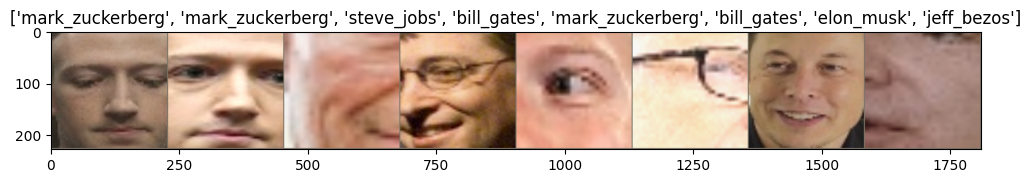

In [12]:
# Создаем сетку из картинок
import torchvision
out = torchvision.utils.make_grid(inputs[:8]) # Покажем первые 8 картинок батча
imshow(out, title=[class_names[x] for x in classes[:8]])

# 3. Выбор предобученной модели и замена классификатора

In [13]:
# Используется предобученная модель
# Возьмем ResNet18 - это классика, работает отлично и быстро.
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


In [15]:
# Замена последнего слоя (классификатора)
# У ResNet последний слой называется 'fc' (fully connected).
num_ftrs = model.fc.in_features
num_classes = len(class_names) # У нас 5 классов

In [16]:
# Создаем новый линейный слой. У него по умолчанию requires_grad=True
model.fc = nn.Linear(num_ftrs, num_classes)

In [17]:
# Функция потерь (многоклассовая классификация)
criterion = nn.CrossEntropyLoss()

In [18]:
# Оптимизатор. Обучаем все параметры замененного слоя
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 4. Обучение многоклассового классификатора

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Каждую эпоху проходим тренировочную и валидационную фазы
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Обучение происходит на обучающей выборке
            else:
                model.eval()   # Режим оценки

            running_loss = 0.0
            running_corrects = 0

            # Итерация по данным
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Обнуляем градиенты параметров
                optimizer.zero_grad()

                # Прямой проход (forward)
                # Отслеживаем историю вычислений только в фазе train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Обратный проход и оптимизация только в фазе train
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Статистика
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Сохраняем лучшую модель
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

        print()

    print(f'Обучение завершено. Лучшая валидационная точность: {best_acc:4f}')

    # Загружаем лучшие веса модели
    model.load_state_dict(best_model_wts)
    return model

# Переносим модель на GPU перед обучением
model = model.to(device)

# Запускаем обучение
model = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
----------
Train Loss: 0.6910 Acc: 0.7447
Valid Loss: 0.1030 Acc: 0.9683

Epoch 2/10
----------
Train Loss: 0.3078 Acc: 0.8923
Valid Loss: 0.0777 Acc: 0.9792

Epoch 3/10
----------
Train Loss: 0.2332 Acc: 0.9193
Valid Loss: 0.0798 Acc: 0.9748

Epoch 4/10
----------
Train Loss: 0.1985 Acc: 0.9290
Valid Loss: 0.0401 Acc: 0.9912

Epoch 5/10
----------
Train Loss: 0.1936 Acc: 0.9323
Valid Loss: 0.0332 Acc: 0.9934

Epoch 6/10
----------
Train Loss: 0.1785 Acc: 0.9390
Valid Loss: 0.0476 Acc: 0.9847

Epoch 7/10
----------
Train Loss: 0.1434 Acc: 0.9513
Valid Loss: 0.0254 Acc: 0.9956

Epoch 8/10
----------
Train Loss: 0.1618 Acc: 0.9470
Valid Loss: 0.0329 Acc: 0.9934

Epoch 9/10
----------
Train Loss: 0.1314 Acc: 0.9537
Valid Loss: 0.0321 Acc: 0.9912

Epoch 10/10
----------
Train Loss: 0.1263 Acc: 0.9567
Valid Loss: 0.0504 Acc: 0.9880

Обучение завершено. Лучшая валидационная точность: 0.995624


# 5. Визуализация предсказаний

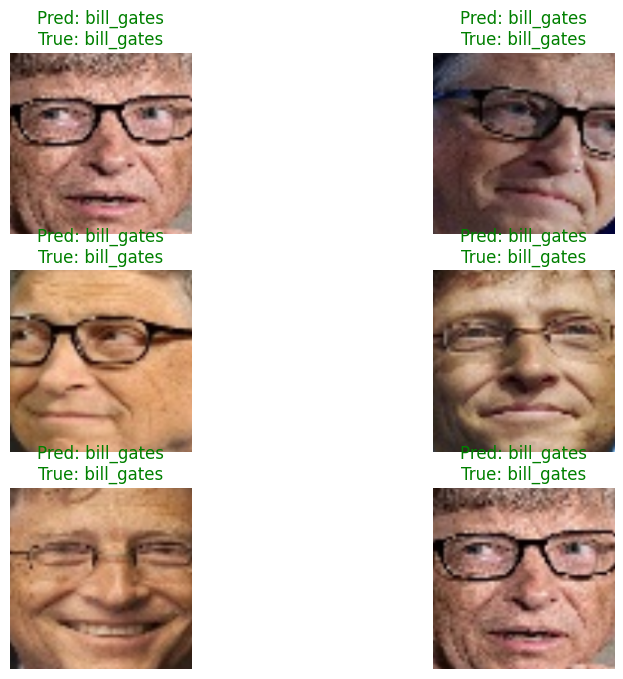

In [20]:
def visualize_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(10, 8))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['valid']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')

                # Имя класса: Предсказанное (Истинное)
                true_class = class_names[labels[j]]
                pred_class = class_names[preds[j]]

                # Меняем цвет заголовка в зависимости от правильности
                color = 'green' if pred_class == true_class else 'red'
                ax.set_title(f'Pred: {pred_class}\nTrue: {true_class}', color=color)

                # Денормализация для показа
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                plt.imshow(img)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Визуализация
visualize_predictions(model)
plt.show()